# Exploring Dataset

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv('/content/flickr_processed.csv')

In [ ]:
data.head()

,prompt,compact_img
0,A person in a red shirt is standing with arms...,b'\x06\x06\x06\x06\x06\x07\x07\x07\x07\x07\x07...
1,The child has a small red guitar and toy micro...,b'\x06\x06\x06\x06\x06\x07\x06\x07\x08\x06\x07...
2,The person is in a conoe and holding a paddle ...,b'\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t...
3,The purple parachutes floats off the cliff tow...,b'\x0b\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c...
4,Two people on a grassy plain are gathering a p...,b'\x04\x03\x04\x04\x03\x03\x03\x03\x03\x04\x05...


In [ ]:
import ast

# Function to transform byte array into 64x64 pillow object
def bytearray_to_image(arr):
  b = ast.literal_eval(arr)
  arr_compact = np.frombuffer(b, dtype=np.uint8)
  if arr_compact.size != 64 * 64:
    raise ValueError(f"Expected {64 * 64} pixels, got {arr_compact.size}")

  arr_full = (arr_compact.astype(np.uint16) * 16).clip(0, 255).astype(np.uint8)
  arr_img = arr_full.reshape((64, 64))
  img = Image.fromarray(arr_img, mode="L")

  return img

A person in a red shirt is standing  with arms raised  at the top of a mountain:


/tmp/ipython-input-3371478998.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr_img, mode="L")


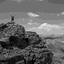

The child has a small red guitar and toy microphone:


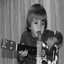

The person is in a conoe and holding a paddle in front of some mountains:


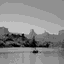

The purple parachutes floats off the cliff toward the grey ocean below:


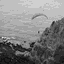

Two people on a grassy plain are gathering a parachute that one of the people just used:


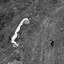

In [ ]:
selected_images = data.head(5)

for i in range(5):
    print(f'{selected_images['prompt'].iloc[i]}:')
    img_array = selected_images['compact_img'].iloc[i]
    image = bytearray_to_image(img_array)
    display(image)

Split dataset for training, validation and testing

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data['prompt'], data['compact_img'], test_size=0.2, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=42)

# Implementing LLM

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [ ]:
class ImageTextDataset(Dataset):
    def __init__(self, tokenizer, prompt, pixelarray):
        self.tokenizer = tokenizer
        self.prompt = prompt
        self.pixelarray = pixelarray

    def __len__(self): return len(self.pixelarray)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.prompt[idx], dtype=torch.long),
            torch.tensor(self.pixelarray[idx], dtype=torch.long)
        )

In [ ]:
class RedstoneTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=16, num_bins=16):
        super().__init__()
        # Lookup tables for text and pixel embeddings
        self.text_emb = nn.Embedding(vocab_size, d_model)
        self.pixel_emb = nn.Embedding(num_bins, d_model)

        # Single decoder layer for minimal footprint
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=1, dim_feedforward=32, batch_first=True
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=1)

        # Final classification head: Predicts grayscale bin (0-15)
        self.to_logits = nn.Linear(d_model, num_bins)

    def forward(self, text_tokens, image_pixels):
        # Text context remains static; pixels attend to previous pixels
        src = self.text_emb(text_tokens)
        tgt = self.pixel_emb(image_pixels)

        # Generate mask to prevent looking at 'future' pixels
        mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)

        out = self.transformer(tgt, src, tgt_mask=mask)
        return self.to_logits(out)

# --- TRAINING PIPELINE ---
def train_model(model, dataloader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        for text, pixels in dataloader:
            # Predict tokens shifted by 1 (standard autoregressive task)
            target = pixels[:, 1:]
            input_seq = pixels[:, :-1]

            optimizer.zero_grad()
            output = model(text, input_seq)

            loss = criterion(output.transpose(1, 2), target)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")